In [43]:
#Cell 1: import
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import requests
import os
from gwosc.datasets import find_datasets
from gwosc import datasets
import time
import tarfile
import io
from astropy.io import fits
from ligo.skymap.io import read_sky_map
from ligo.skymap import postprocess
import dustmaps.sfd
from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.stats import binned_statistic_2d

In [4]:
target_nside = 1024  # everything gets brought up to this. This is so I can do pixel by pixel comparisons


In [6]:
#Cell 2: getting all GWTC events
url = "https://gwosc.org/api/v2/catalogs/GWTC/events"
params = {"include-default-parameters": "true", "pagesize": 20}

all_events = []

while True:
    #Send a GET request to GWOSC with page number as a query parameter
    response = requests.get(url, params)
    #for page 1, this is the same thing as: https://gwosc.org/api/v2/catalogs/GWTC/events?include-default-parameters=true&pagesize=20&page=1
    
    # Parse the JSON body into a Python dictionary
    data = response.json()

    #grab event data, which is under "results," and add to running list
    all_events.extend(data["results"])

    # If there's no next page, stop looping
    if data["next"] is None:
        break

    # Otherwise advance to the next page
    url = data["next"] #next page url is under "next"
    params = {} #clearing because next url has all the parameters
    time.sleep(0.5)  #wait half a second between requests to not overload the server

print(f"\nTotal events fetched: {len(all_events)}") #for debugging


Total events fetched: 391


In [8]:
#Cell 3: filtering for BBH events
def is_bbh(event):
    params = {p["name"]: p["best"] for p in event.get("default_parameters", [])} #return empty list if "default_parameters" is somehow missing
    #get the list under dictionary key "default paraemeters" in event, and we are traversing each item p in the list, which are dictionaries, and make take p["name"] the keys and p["best"] as values for this new dictionary params
    mass_one = params.get("mass_1_source", 0)  # returns 0 if missing, won't crash
    mass_two = params.get("mass_2_source", 0)  # returns 0 if missing, won't crash
    return mass_one > 3 and mass_two > 3

bbh_events = [e for e in all_events if is_bbh(e)] #filter
print(f"Total events: {len(all_events)}") #for debugging
print(f"BBH events: {len(bbh_events)}") #for debugging
for e in bbh_events[:5]:
    print(e["name"]) #for debugging

Total events: 391
BBH events: 273
GW250119_190238
GW250119_025138
GW250118_170523
GW250118_055802
GW250118_023225


In [13]:
#Cell 4: Collect all events with skymaps

url = "https://gwosc.org/api/v2/event-versions?release=GWTC-1-confident%2CGWTC-2.1-confident%2CGWTC-3-confident%2CGWTC-4.0&lastver=true&include-default-parameters=true&format=json"
#this is the url for GWTC-4.0 cumulative. Replace this once GWTC-5.0 has skymaps

bbh_with_skymaps = []

while True:
    #GET request
    response = requests.get(url, {})
    # Parse the JSON body into a Python dictionary
    data = response.json()
    for event in data["results"]: #results is a dictionary
        if is_bbh(event):
            bbh_with_skymaps.append(event)
    if data["next"] is None:
        break
    url = data["next"]
    time.sleep(0.5)

print(f"Total bbh events with skymaps: {len(bbh_with_skymaps)}")

Total bbh events with skymaps: 167


In [35]:
#Cell 5: Get skymap URLS from bbh_with_skymaps
# GWTC-1: individual .fits.gz files on DCC, one per event
# GWTC-2.1 and GWTC-3: skymap URL is in the API under "label": "skymap" on the preferred result
# GWTC-4.0: single tar.gz on Zenodo containing all events

#GWTC-1 skymaps have been absorbed into GWTC-2.1
#GWTC1_SKYMAP_URL = "https://dcc.ligo.org/public/0157/P1800381/007/{name}_skymap.fits.gz"
GWTC4_SKYMAP_TAR = "https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Skymaps.tar.gz?download=1"

def get_parameters_with_retry(url, max_retries=3):
    for attempt in range(max_retries):
        response = requests.get(url, {})
        if response.status_code == 200 and response.text.strip():
            return response.json()
        print(f"    Attempt {attempt + 1} failed (status={response.status_code}), retrying in {2 ** attempt}s...")
        time.sleep(2 ** attempt)  # wait 1s, then 2s, then 4s
    return None  # all retries failed

skymap_urls = {}  # name -> url or tar info

for event in bbh_with_skymaps:
    name = event["name"]
    catalog = event["catalog"]

    # if catalog == "GWTC-1-confident":
    #     skymap_urls[name] = GWTC1_SKYMAP_URL.format(name=name)
    if catalog in ("GWTC-2.1-confident","GWTC-3-confident"):
        short_name = event["shortName"] 
        parameters_url = f"https://gwosc.org/api/v2/event-versions/{short_name}/parameters?format=json"

        data = get_parameters_with_retry(parameters_url)
        if data is None:
            print(f"  FAILED after all retries: {name}")
            continue

        found = False
        for result in data["results"]:
            if result["is_preferred"]:
                for link in result["links"]:
                    if link["label"] == "skymap":
                        skymap_urls[name] = link["url"]
                        found = True
        
        if not found:
            print(f"  WARNING: no skymap link found for {name} ({catalog})")

        time.sleep(0.3)

    elif catalog == "GWTC-4.0":
        skymap_urls[name] = GWTC4_SKYMAP_TAR

print(f"Skymap URLs found: {len(skymap_urls)} / {len(bbh_with_skymaps)}")
for name, url in list(skymap_urls.items())[:5]:
    print(f"  {name}: {url[:80]}...")


Skymap URLs found: 167 / 167
  GW240109_050431: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW240107_013215: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW240104_164932: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW231231_154016: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  GW231230_170116: https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...


In [27]:
# Cell 6: Find skymap URLs
#.tar.gz is just a compressed folder

os.makedirs("skymaps", exist_ok=True)  # create skymaps folder if it doesn't exist

# find all unique tar URLs (GWTC-2.1 and GWTC-3 events may share the same tar)
unique_tars = {}  # tar_url -> list of event names that use it
gwtc1_events = {}  # event name -> individual URL (not a tar)

for event in bbh_with_skymaps:
    name = event["name"]
    catalog = event["catalog"]
    url = skymap_urls[name]

    if catalog == "GWTC-1-confident":
        gwtc1_events[name] = url  # individual file, handle separately
    else:
        if url not in unique_tars:
            unique_tars[url] = []
        unique_tars[url].append(name)  # group events by their tar URL

print(f"Individual GWTC-1 files to download: {len(gwtc1_events)}")
print(f"Unique tar archives to download: {len(unique_tars)}")
for url, names in unique_tars.items():
    print(f"  {url[:60]}...  ({len(names)} events)")

Individual GWTC-1 files to download: 0
Unique tar archives to download: 4
  https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214...  (84 events)
  https://zenodo.org/api/records/8177023/files/IGWN-GWTC3p0-v2...  (32 events)
  https://zenodo.org/api/records/6513631/files/IGWN-GWTC2p1-v2...  (41 events)
  https://zenodo.org/api/files/ecf41927-9275-47da-8b37-e299693...  (10 events)


In [42]:
#Cell 7: Download and extract skymaps for all 167 BBH events with the skymap URLs I just found in unique_tars
os.makedirs("skymaps", exist_ok=True) #create new dir on computer
for tar_url, event_names in unique_tars.items():
    print(f"\nDownloading tar for {len(event_names)} events...")
    print(f"  {tar_url[:80]}...") #for debugging

    # Stream to a temp file on disk instead of into RAM
    tar_path = "skymaps/_temp.tar.gz"
    with requests.get(tar_url, stream=True) as response:
        with open(tar_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8 * 1024 * 1024):  # 8MB chunks
                f.write(chunk)
    print(f"  Download complete, extracting...")

    with tarfile.open(tar_path, mode="r:gz") as tar:
        all_files = tar.getnames()
        for name in event_names:
            matches = [f for f in all_files if name in f and (f.endswith(".fits") or f.endswith(".fits.gz"))]
            ext = ".fits.gz" if matches and matches[0].endswith(".fits.gz") else ".fits"
            save_path = f"skymaps/{name}_skymap{ext}"
            if os.path.exists(save_path):
                print(f"  {name}: already exists, skipping")
                continue
            if len(matches) == 0:
                print(f"  {name}: no matching .fits file found in tar")
                continue
            if len(matches) > 1:
                print(f"  {name}: multiple matches, using first: {matches[0]}")
            member = tar.getmember(matches[0])
            with tar.extractfile(member) as f_in:
                with open(save_path, "wb") as f_out:
                    f_out.write(f_in.read())
                    print(f"  {name}: saved")
    os.remove(tar_path)  # clean up temp file
    print(f"  Temp file removed")

print("\nDone!")
print(f"Files in skymaps/: {len(os.listdir('skymaps'))}")


  https://zenodo.org/records/17602505/files/IGWN-GWTC4p0-38214bd95_724-Archived_Sk...
  Download complete, extracting...
  GW240109_050431: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240109_050431-Mixed_Skymap_PEDataRelease.fits.gz
  GW240109_050431: saved
  GW240107_013215: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240107_013215-Mixed_Skymap_PEDataRelease.fits.gz
  GW240107_013215: saved
  GW240104_164932: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW240104_164932-Mixed_Skymap_PEDataRelease.fits.gz
  GW240104_164932: saved
  GW231231_154016: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW231231_154016-SEOBNRv5PHM_Skymap_PEDataRelease.fits.gz
  GW231231_154016: saved
  GW231230_170116: multiple matches, using first: parameter_estimation/skymaps/IGWN-GWTC4p0-38214bd95_724-GW231230_170116-SEOBNRv5PHM_Skymap_PED

In [43]:
os.remove("skymaps/_inspect.tar.gz")

In [7]:
#Cell 8: Loading one skymap (GW150914) to inspect
# Peek inside the file first
test_file = "skymaps/GW150914_skymap.fits"
with fits.open(test_file) as hdul:
    hdul.info()
    print(hdul[1].columns)

# Read and convert to a flat healpy map
skymap, metadata = read_sky_map(test_file, nest=True)

print(f"Number of pixels: {len(skymap)}")
print(f"NSIDE: {hp.npix2nside(len(skymap))}")
print(f"Sum (should be ~1.0): {skymap.sum():.6f}")

Filename: skymaps/GW150914_skymap.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     41   16896R x 5C   [K, D, D, D, D]   
ColDefs(
    name = 'UNIQ'; format = 'K'
    name = 'PROBDENSITY'; format = 'D'; unit = 'sr-1'
    name = 'DISTMU'; format = 'D'; unit = 'Mpc'
    name = 'DISTSIGMA'; format = 'D'; unit = 'Mpc'
    name = 'DISTNORM'; format = 'D'; unit = 'Mpc-2'
)
Number of pixels: 3145728
NSIDE: 512
Sum (should be ~1.0): 1.000000


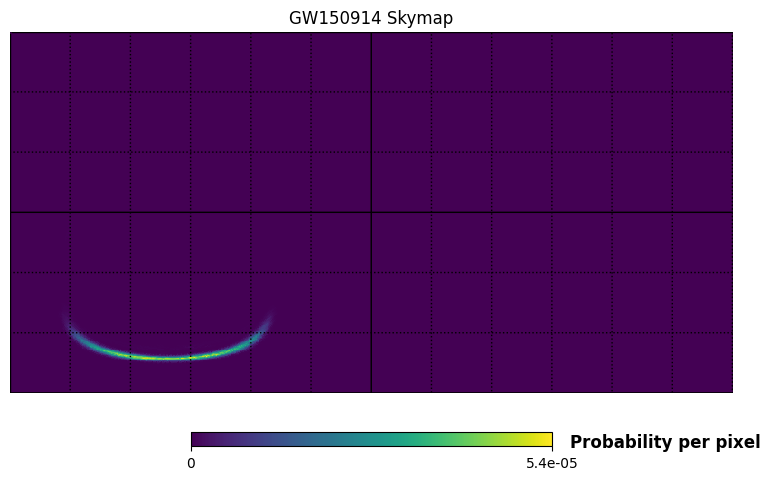

In [10]:
#Cell 9: Plot a single skymap (GW150914) as equirectangular projection
# Convert from nested to ring ordering (required for mollview/cartview)
skymap_ring = hp.reorder(skymap, n2r=True)
# Resample to target_nside BEFORE computing 90% region
skymap_ring = hp.ud_grade(skymap_ring, target_nside, order_in='RING', order_out='RING')
skymap_ring /= skymap_ring.sum()  # renormalize after resampling


# Equirectangular projection
hp.cartview(
    skymap_ring,
    title="GW150914 Skymap",
    unit="Probability per pixel",
    cmap="viridis",
    fig=1
)
hp.graticule()  # adds grid lines
plt.show()

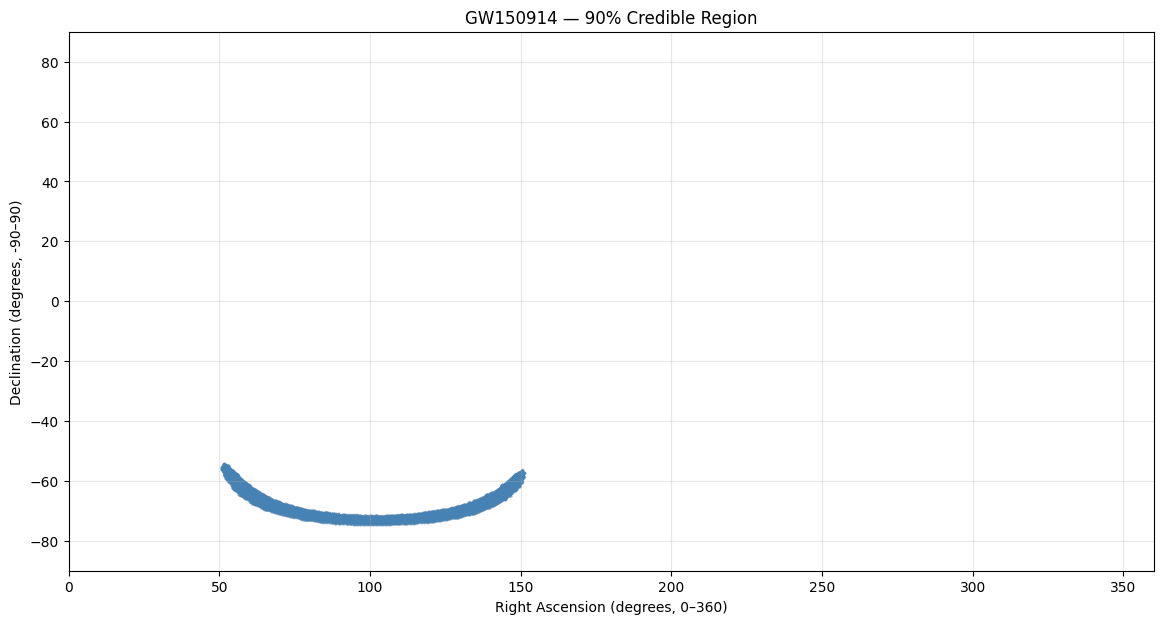

In [11]:
#Cell 10: Compute and plot the 90% credible region contour for GW150914
# Sort pixels by probability, highest first
# Then find the minimum number of pixels that sum to 90% of total probability

sorted_indices = np.argsort(skymap_ring)[::-1]  
#returns the indices that would sort the array from lowest to highest. [::-1] reverses it so it's highest to lowest.
cumsum = np.cumsum(skymap_ring[sorted_indices])  #an array containing running total of probability (cumulative sums)
threshold = cumsum.searchsorted(0.90)  # how many pixels to reach 90%, ie the index of cumsum where we reach 0.9

# Make a binary map: 1 inside 90% region, 0 outside
confidence_map = np.zeros(len(skymap_ring)) #reates a new array of zeros, same length as the skymap.
confidence_map[sorted_indices[:threshold]] = 1.0 #make binary map where every pixel up to the threshold is set to 1.0

# Convert every pixel center to (ra, dec) coordinates to plot as scatter plot
npix = hp.nside2npix(target_nside)
theta, phi = hp.pix2ang(target_nside, np.arange(npix), nest=False) #Converts all pixel indices to spherical coordinates: theta (colatitude) and phi (longitude)

# healpy uses physics convention: theta=colatitude (0=north pole), phi=longitude
#Convert from HEALPix's physics convention to astronomical coordinates (RA/Dec).
dec = 90 - np.degrees(theta)  # convert to declination (-90 to 90)
ra = np.degrees(phi)           # convert to RA (0 to 360)

# Only plot pixels inside the 90% region
inside = confidence_map == 1.0 #Create a boolean mask selecting only pixels inside the 90% region (value = 1.0).
plt.figure(figsize=(14, 7))
plt.scatter(ra[inside], dec[inside], s=0.01, c="steelblue", alpha=0.5) #Plots only the credible region pixels as points on an RA/Dec grid.
plt.xlabel("Right Ascension (degrees, 0–360)")
plt.ylabel("Declination (degrees, -90–90)")
plt.title("GW150914 — 90% Credible Region")
#Sets axis ranges to match standard astronomical coordinates.
plt.xlim(0, 360)
plt.ylim(-90, 90)
plt.grid(True, alpha=0.3)
plt.show()

Color palette: 170 colors: red→yellow→green→cyan→blue→magenta


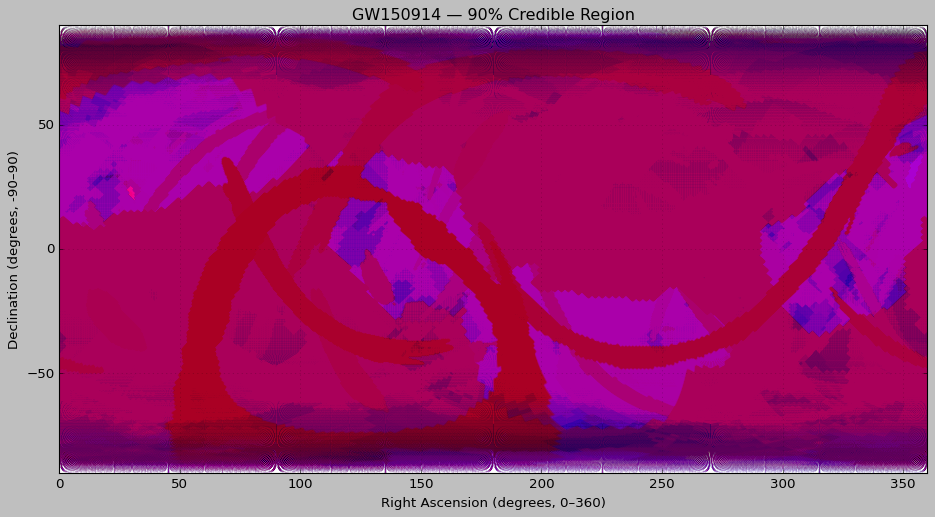


✓ Successfully processed: 167 events
✗ Failed: 0 events


In [47]:
#Cell 11: Plot all BBH events on one master equirectangular map

#master plot:
plt.style.use('classic')         
plt.figure(figsize=(14, 7))
plt.xlabel("Right Ascension (degrees, 0–360)")
plt.ylabel("Declination (degrees, -90–90)")
plt.title("GW150914 — 90% Credible Region")
#Sets axis ranges to match standard astronomical coordinates.
plt.xlim(0, 360)
plt.ylim(-90, 90)
plt.grid(True, alpha=0.3)

failed = 0
successful = 0

# Create 170 colors by explicitly sampling hue across full spectrum
n_colors = 170
hues = np.linspace(0, 1, n_colors, endpoint=False)
colors = [plt.matplotlib.colors.hsv_to_rgb((h, 1, 1)) for h in hues]  # Full saturation and brightness
print(f"Color palette: {len(colors)} colors: red→yellow→green→cyan→blue→magenta")

skymap_files = os.listdir("skymaps")

for i, filename in enumerate(skymap_files):
    if not filename.endswith(".fits") and not filename.endswith(".fits.gz"):
        continue

    file = os.path.join("skymaps", filename)
    color = colors[i % len(colors)]  # cycle through colors if needed

    event_name = filename.replace("_skymap.fits.gz", "").replace("_skymap.fits", "") #extracting event name
    
    try:
        # Read and convert to a flat healpy map
        skymap_nested, _ = read_sky_map(file, nest=True)

        #convert to ring ordering
        skymap_ring = hp.reorder(skymap_nested, n2r=True)

        # Resample to target_nside BEFORE computing 90% region
        skymap_ring = hp.ud_grade(skymap_ring, target_nside, order_in='RING', order_out='RING')
        skymap_ring /= skymap_ring.sum()  # renormalize after resampling

        #compute 90% credible region
        sorted_indices = np.argsort(skymap_ring)[::-1]  
        #returns the indices that would sort the array from lowest to highest. [::-1] reverses it so it's highest to lowest.
        cumsum = np.cumsum(skymap_ring[sorted_indices])  #an array containing running total of probability (cumulative sums)
        threshold = cumsum.searchsorted(0.90)  # how many pixels to reach 90%, ie the index of cumsum where we reach 0.9

        # Make a binary map: 1 inside 90% region, 0 outside
        confidence_map = np.zeros(len(skymap_ring)) #reates a new array of zeros, same length as the skymap.
        confidence_map[sorted_indices[:threshold]] = 1.0 #make binary map where every pixel up to the threshold is set to 1.0

        # Convert pixels to RA/Dec coordinates
        npix = hp.nside2npix(target_nside)
        theta, phi = hp.pix2ang(target_nside, np.arange(npix), nest=False) #Converts all pixel indices to spherical coordinates: theta (colatitude) and phi (longitude)
        
        #old, non standardized
        nside = hp.npix2nside(len(skymap_ring))
        npix = len(skymap_ring)
        theta, phi = hp.pix2ang(nside, np.arange(npix), nest=False)

        dec = 90 - np.degrees(theta)  # convert to declination (-90 to 90)
        ra = np.degrees(phi)           # convert to RA (0 to 360)
        
        # Get only the pixels inside the 90% region
        inside = confidence_map == 1.0

        #adding to scatterplot
        plt.scatter(ra[inside], dec[inside], s=0.001, color=color, alpha=0.2)
        successful += 1
            
    except Exception as e:
        failed += 1
        print(f"  ERROR processing {event_name}: {str(e)[:50]}")

 
plt.show()
print(f"\n✓ Successfully processed: {successful} events")
print(f"✗ Failed: {failed} events")

In [4]:
dustmaps.sfd.fetch()

  0.0 B of 64.0 MiB |   0.0 s/B |                       |   0% | ETA:  --:--:--
830.0 KiB of 64.0 MiB |  11.3 MiB/s |                   |   1% | ETA:  00:00:00
  2.2 MiB of 64.0 MiB |  12.6 MiB/s |                   |   3% | ETA:   0:00:04
  4.9 MiB of 64.0 MiB |  12.6 MiB/s |#                  |   7% | ETA:   0:00:04
  6.5 MiB of 64.0 MiB |  21.3 MiB/s |#                  |  10% | ETA:   0:00:02
  7.4 MiB of 64.0 MiB |  17.4 MiB/s |##                 |  11% | ETA:   0:00:03
  8.9 MiB of 64.0 MiB |  17.4 MiB/s |##                 |  13% | ETA:   0:00:03
 10.5 MiB of 64.0 MiB |  19.5 MiB/s |###                |  16% | ETA:   0:00:02
 12.2 MiB of 64.0 MiB |  19.5 MiB/s |###                |  18% | ETA:   0:00:02
 13.8 MiB of 64.0 MiB |  20.8 MiB/s |####               |  21% | ETA:   0:00:02
 15.4 MiB of 64.0 MiB |  20.8 MiB/s |####               |  24% | ETA:   0:00:02
 17.0 MiB of 64.0 MiB |  21.9 MiB/s |#####              |  26% | ETA:   0:00:02
 18.2 MiB of 64.0 MiB |  19.1 MiB/s |###

  0.0 B of 64.0 MiB |   0.0 s/B |                       |   0% | ETA:  --:--:--
830.0 KiB of 64.0 MiB |   8.7 MiB/s |                   |   1% | ETA:  00:00:00
  1.6 MiB of 64.0 MiB |  10.4 MiB/s |                   |   2% | ETA:   0:00:06
  2.4 MiB of 64.0 MiB |  10.4 MiB/s |                   |   3% | ETA:   0:00:05
  3.2 MiB of 64.0 MiB |  12.4 MiB/s |                   |   5% | ETA:   0:00:04
  4.9 MiB of 64.0 MiB |  12.4 MiB/s |#                  |   7% | ETA:   0:00:04
  6.5 MiB of 64.0 MiB |  15.0 MiB/s |#                  |  10% | ETA:   0:00:03
  6.8 MiB of 64.0 MiB |  12.8 MiB/s |##                 |  10% | ETA:   0:00:04
  8.1 MiB of 64.0 MiB |  12.8 MiB/s |##                 |  12% | ETA:   0:00:04
  9.7 MiB of 64.0 MiB |  14.8 MiB/s |##                 |  15% | ETA:   0:00:03
 11.3 MiB of 64.0 MiB |  14.8 MiB/s |###                |  17% | ETA:   0:00:03
 13.0 MiB of 64.0 MiB |  16.4 MiB/s |###                |  20% | ETA:   0:00:03
 14.6 MiB of 64.0 MiB |  16.4 MiB/s |###

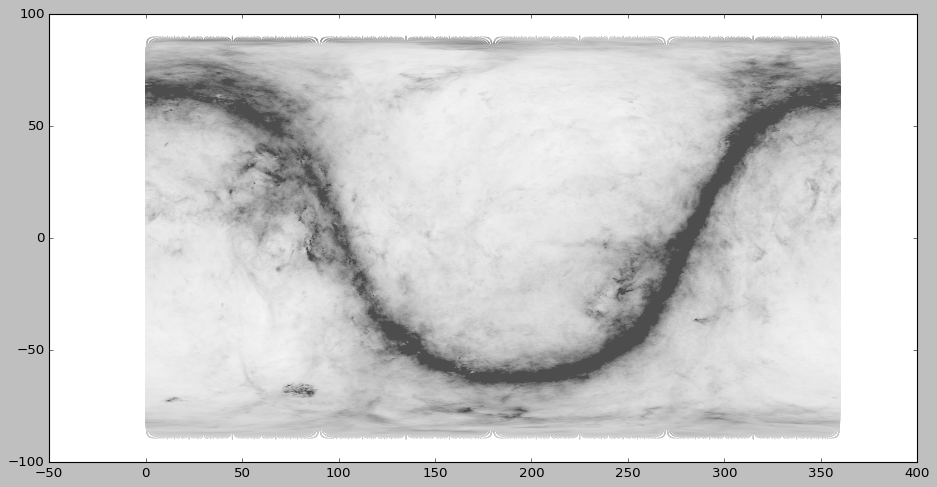

In [23]:
#Cell 12: overlay milky way
# Sample the dust map at every HEALPix pixel center
# nside = 512  # Higher resolution for better dust map detail
npix  = hp.nside2npix(target_nside)
theta, phi = hp.pix2ang(target_nside, np.arange(npix))

ra  = np.degrees(phi)
dec = 90 - np.degrees(theta)

# Query SFD dust map
coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame='icrs')
sfd    = SFDQuery()
ebv    = sfd(coords)

# Normalize and create alpha values
ebv_clipped = np.clip(ebv, 0, 1.5)
alpha_vals  = (ebv_clipped / 1.5) ** 0.5

# Plot dust map with gradient: white (no dust) → light gray (medium) → dark gray (high dust)
mask = alpha_vals > 0.01  # Only plot pixels with meaningful dust
# Map dust to grayscale: 1.0 (white) for no dust, 0.3 (dark gray) for high dust
gray_values = 1.0 - 0.7 * alpha_vals[mask]
colors_dust = np.repeat(gray_values[:, np.newaxis], 3, axis=1)

plt.figure(figsize=(14, 7))
plt.scatter(
    ra[mask], dec[mask],
    s=1.0,
    c=colors_dust,
    linewidths=0,
    rasterized=True
)
plt.show()

#eventually put this with the bbh events

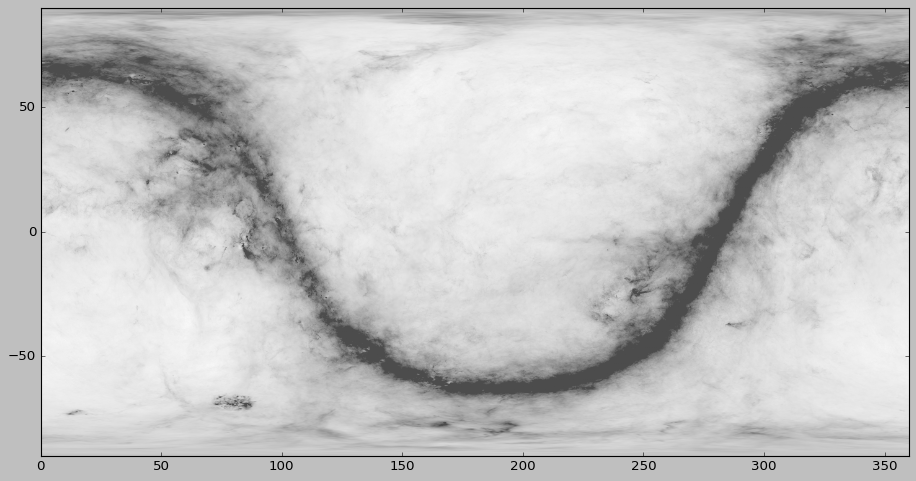

In [ ]:
#Cell 12: SFD display with imshow
# Build regular 2D grid
ra_grid  = np.linspace(0, 360, 1400) #an array from 0 to 360 with 1400 steps (1 for each pixel)
dec_grid = np.linspace(-90, 90, 700) #an array from -90 to 90 with 700 steps (1 for each pixel)
ra_2d, dec_2d = np.meshgrid(ra_grid, dec_grid) #creates two 2D arrays with ra_grid as rows for ra_2D and dec_grid as columns for dec_2D to store ra and dec for every pixel

# Query SFD at every grid point
#creating proper coordinates
coords = SkyCoord(
    ra=ra_2d.ravel() * u.deg, #ravel flattens the 2D grid into a 1D list of 980,000 coordinates (700×1400)
    dec=dec_2d.ravel() * u.deg, 
    frame='icrs'
)
sfd = SFDQuery()
#ebv for dust in line of sight
ebv = sfd(coords).reshape(700, 1400)  #reshape from 1D list back to 2D grid

# Normalize to grayscale
ebv_clipped = np.clip(ebv, 0, 1.5) #cap at 1.5 because anything above is also very dusty
gray_grid = 1.0 - 0.7 * (ebv_clipped / 1.5) ** 0.5  # white=low dust, dark=high dust
#ebv_clipped / 1.5 -> 0 to 1 range
#** 0.5 square root stretch (so low dust values higher contrast)
#0.7 to prevent pure black
#1- to invert so low dust is white and high dust is dark grey

# Plot. fig is base. Plotting dust on top of it.
fig, ax = plt.subplots(figsize=(14, 7))
#same as: fig = plt.figure(figsize=(14, 7) and ax = fig.add_subplot(111)
ax.imshow(gray_grid, origin='lower', extent=[0, 360, -90, 90],
          cmap='gray', vmin=0, vmax=1, aspect='auto')
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
plt.show()


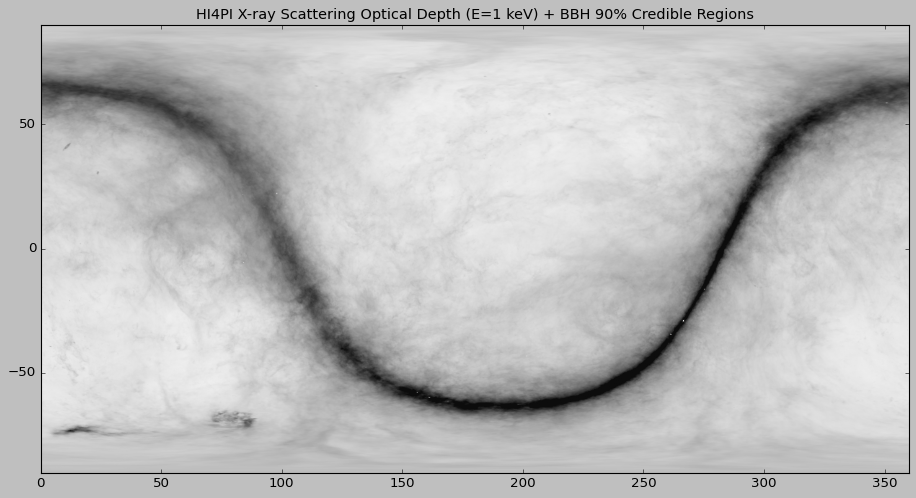

In [ ]:
# Cell 13: HI4PI column density → X-ray scattering optical depth
#HEALPix data → regular grid → matplotlib imshow → overlay BBH scatter on top

#Convert N_H to X-ray scattering optical depth
#variables:
#mass densities: rho_dust, rho_gas, rho_grain (of dust grain material)
#m_p = 1 proton mass; applicable because most interstellar gas is hydrogen
#m_g = (4π/3) * a^3 * rho_grain; a = radius of dust particle (assuming it is spherical)
#column densities: N_H (hydrogen), N_d (dust)
#N_d = 0.01 * N_H * m_p / m_g

#to calculuate optical depth for dust scattering of X-rays, use τ_scattering (scattering probability of x-rays)

#differential scattering cross section dσ/dΩ = 2a^2 * (2πa/λ)^ 4 * |m − 1|^2 * (j_1(x) / x) ^ 2 * (1 + cos^2θ) cm^2 sr^−1 (steradian)
#x = (4πa/λ) * sin(θ/2)
#θ = angle through which the photon trajectory is deflected by the scattering
#j_1(x) is the spherical Bessel function of order 1
#m is the index of refraction of the grain material
#The probability that a photon will be scattered into any direction is the integral of dσ_scattering/dΩ over the entire sky (over all angles). 
#integrate to get σ_scattering = 2πa2 * (2πa/λ)^2 * |m − 1|^2

# Given cartesian coordinate system with scattering particle at the origin, let incoming photon come up along the z-axis and be scattered by the scattering particle at the origin
# scattering angle θ: polar angle between the direction of travel of the scattered photon and the positive z−axis
# Note: scattering geometry is azimuthally symmetric around the z−axis, so the scattering probability does not depend on the azimuthal angle φ (that is the angle between the projection of the outgoing photon direction onto the x − y−plane, and the positive x−axis). 
# pick range of angles θ → θ + dθ. These angles form an annulus in the sky of width dθ
# to figure out the solid angle of this annulus, center a sphere of radius r at origin and project the annulus onto the sphere
# its projection will have a radius rsinθ and width rdθ. it will have a surface area 2πr^2 * sinθ * dθ (ie: 2pi * radius * width)
# solid angle is defined as A/r^2 so the solid angle of this annulus is dΩ = 2π * sinθ * dθ
# integrate to get solid angle Ω between any θ_1 and θ_2 by integrating

#The probability that a photon will be scattered into the range of angles  θ → θ + dθ is
# dτ = ndl * (dσ_scattering / dΩ) * dΩ = ndl * (dσ_scattering / dΩ) * 2π * sinθ * dθ
#dl = the infinitesimal distance the photon travels
#n = the density of scattering particles per unit volume

#scattering probability = 1 − e ^ (−optical depth)
#if optical depth << 1, scattering probability is approx. = optical depth
#τ_scattering is optical depth

#in this case, we will say x << 1 so σ_scattering = (6.3 × 10^ −11) * (2Z/M)^2 * (ρ/3)^2 * (a/0.1 microns)^4 * (E/keV)^-1  * (F(E)/Z)^2 cm^2
#Z = nuclear charge of the atoms in the dust material
#M = the atomic mass of those atoms
#ρ = ρ_grains
#E = photon energy
#F(E) = atomic scattering function
#far away from resonances,  |F(E)| ≈ Z


# Assumtions: 
# #proton energy E = 1 keV
# a = 0.1 micrometers
# ρ_grain = 3 g cm^-3
# gas density of interstellar medium (ISM) n = 1 H atom cm^-3

#optical depth
#τ_scattering = N_d * σ_scattering
#τ_scattering = (8.4 × 10^−23) * N_H * (a / 0.1 micron) * (ρ/3) E_keV^-1

#Note: this approximation breaks down for  low photon energies, large grain sizes, and large scattering angles

#Load and regrade HI4PI map, which gives column densities
with fits.open("NHI_HPX.fits") as hdul: #with to close file when done
    data = hdul[1].data #hdul[1] is actual data table
    hpx_index = data['HPXINDEX'] #healpy pixel index
    nhi_values = data['NHI']

npix_hi  = hp.nside2npix(target_nside)
hi_map   = np.zeros(npix_hi) #creating empty healPix array
hi_map[hpx_index] = nhi_values #filling array with col densities by linking densities to each pixel like in the og file

# All three are at reference values so all three terms = 1
a  = 0.1
rho_grain = 3.0
E_keV = 1.0 

#a numpy array built off of hi_map's col density values
tau_scattering = 8.4e-23 * hi_map * a/1.0 * rho_grain/3 * (E_keV ** -1)

#healpy uses (theta, phi)
#HI4PI is stored in galactic (l, b) 
#matplotlib uses equatorial (ra, dec)

# Build regular 2D grid
ra_grid  = np.linspace(0, 360, 1400) #an array from 0 to 360 with 1400 steps (1 for each pixel)
dec_grid = np.linspace(-90, 90, 700) #an array from -90 to 90 with 700 steps (1 for each pixel)
ra_2d, dec_2d = np.meshgrid(ra_grid, dec_grid) #creates two 2D arrays with ra_grid as rows for ra_2D and dec_grid as columns for dec_2D to store ra and dec for every pixel

#the coordinates I need
coords_grid = SkyCoord( #create an astropy coordinate object
    ra=ra_2d.ravel()*u.deg,   # flatten 2D → 1D for SkyCoord
    dec=dec_2d.ravel()*u.deg, 
    frame='icrs'
)

#converting the coordinates I need to galactic
l_grid = coords_grid.galactic.l.deg.reshape(700, 1400)  # reshape to 2D
b_grid = coords_grid.galactic.b.deg.reshape(700, 1400)  # reshape to 2D

#converting to theta/phi for healpy. Putting the right coordinates in the right pixels?
theta_grid = np.radians(90 - b_grid)  # convert dec_grid to healpy theta
phi_grid   = np.radians(l_grid)        # convert ra_grid to healpy phi

#find pixel value
pix_idx  = hp.ang2pix(target_nside, theta_grid, phi_grid)  #returns galactic pixel index from the value according to target_nside! 
tau_grid = tau_scattering[pix_idx]  # look up tau value at each grid point. Happens that target_nside = native file nside so we good!

# Normalize to grayscale
#cutting out top 0.5% to maintain some contrast in the gray
tau_clipped  = np.clip(tau_grid, 0, np.percentile(tau_grid, 99.5))
tau_clipped -= tau_clipped.min()
tau_clipped /= tau_clipped.max()
gray_grid    = 1.0 - 0.95 * np.sqrt(tau_clipped)  # white=low tau, dark=high tau
#square root stretch to increase contrast for low values
#0.95 so not pure black
#1- to invert so dense is dark, sparse is light

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(gray_grid, origin='lower', extent=[0, 360, -90, 90],
          cmap='gray', vmin=0, vmax=1, aspect='auto')
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)
ax.set_title("HI4PI X-ray Scattering Optical Depth (E=1 keV) + BBH 90% Credible Regions", fontsize=13)

plt.show()



In [49]:
print(f"HI map max (N_H): {hi_map.max():.3e}")
print(f"HI map min (N_H): {hi_map.min():.3e}")
print(f"HI map mean (N_H): {hi_map.mean():.3e}")

HI map max (N_H): 3.600e+02
HI map min (N_H): 4.355e-05
HI map mean (N_H): 1.800e+02


In [54]:
print(f"l_grid range: {l_grid.min():.1f} to {l_grid.max():.1f}")
print(f"b_grid range: {b_grid.min():.1f} to {b_grid.max():.1f}")
print(f"tau_grid range: {tau_grid.min():.4f} to {tau_grid.max():.4f}")
print(f"tau_grid[350, 0]: {tau_grid[350, 0]:.4f}")    # middle left
print(f"tau_grid[350, 700]: {tau_grid[350, 700]:.4f}") # middle center
print(f"tau_grid[350, 1399]: {tau_grid[350, 1399]:.4f}") # middle right
print(f"hi_map range: {hi_map.min():.2f} to {hi_map.max():.2f}")
print(f"tau_scattering range: {tau_scattering.min():.4f} to {tau_scattering.max():.4f}")
hi_map_raw = hp.read_map("NHI_HPX.fits")
print(f"raw hi_map range: {hi_map_raw.min():.2f} to {hi_map_raw.max():.2f}")
print(f"raw nside: {hp.npix2nside(len(hi_map_raw))}")
print(f"target_nside: {target_nside}")

l_grid range: 0.0 to 360.0
b_grid range: -90.0 to 89.9
tau_grid range: 0.0000 to 0.0000
tau_grid[350, 0]: 0.0000
tau_grid[350, 700]: 0.0000
tau_grid[350, 1399]: 0.0000
hi_map range: 0.00 to 360.00
tau_scattering range: 0.0000 to 0.0000
raw hi_map range: 0.00 to 360.00
raw nside: 1024
target_nside: 1024
